In [1]:
import os
import fastplotlib as fpl
import sys
import masknmf
import tifffile
import torch
import numpy as np

import matplotlib.pyplot as plt
import time
from typing import *
import pathlib
from pathlib import Path

import math
%load_ext line_profiler
%matplotlib inline
%load_ext autoreload

fastplotlib version from git (0.4.0) and __version__ (0.5.0) don't match.


Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),AMD Radeon RX 570 Series (RADV POLARIS10),DiscreteGPU,Vulkan,Mesa 22.3.6
✅,NVIDIA GeForce RTX 3080,DiscreteGPU,Vulkan,575.57.08
❗ limited,"llvmpipe (LLVM 15.0.6, 256 bits)",CPU,Vulkan,Mesa 22.3.6 (LLVM 15.0.6)
❌,"AMD Radeon RX 570 Series (polaris10, LLVM 15.0.6, DRM 3.49, 6.1.0-38-amd64)",Unknown,OpenGL,4.6 (Core Profile) Mesa 22.3.6


pygfx version from git (0.9.0) and __version__ (0.10.0) don't match.


In [2]:
from pprint import pprint

In [3]:
demixing_results = np.load("/home/kushal/amol_data/demixing_plane10.npz", allow_pickle = True)

In [4]:
demixing_results.keys()

KeysView(NpzFile '/home/kushal/amol_data/demixing_plane10.npz' with keys: results, metadata)

In [5]:
dm = demixing_results["results"][()]

In [24]:
dm.shape

(13585, 512, 512)

In [10]:
dm.q[0].shape

torch.Size([7043, 58])

In [6]:
pprint(demixing_results["metadata"][()])

{'background_downsampling_factor': 20,
 'data_field': 'pmd_denoise',
 'data_path': 'outputs_kushal/plane10_results.npz',
 'device': 'cuda',
 'frame_batch_size': 400,
 'out_path': 'outputs_kushal/demixing_plane10.npz',
 'ring_radius': 15,
 'spatial_hp_sigma': 4}


In [7]:
dm.colorful_ac_array.shape

(13585, 512, 512, 3)

In [8]:
dm.a.shape

torch.Size([262144, 929])

In [16]:
dm.a.T[0].cpu().numpy()

TypeError: can't convert Sparse layout tensor to numpy. Use Tensor.to_dense() first.

In [ ]:
from scipy.spatial import ConvexHull

In [18]:
A = dm.a.to_dense()[:, 400].cpu().numpy().reshape(512, 512)

In [ ]:
dm.a.shape

In [ ]:
dm.a

In [13]:
dm.pmd_array.to("cuda")

In [35]:
dm.to("cuda")

In [ ]:
dm.

In [36]:
dm.ac_array.device

device(type='cuda', index=0)

In [37]:
%%timeit
i = np.random.randint(0, 10_000)
dm.ac_array[i]

645 μs ± 5.31 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [16]:
dm.pmd_array[:, 0, 0]

array([ 0.00152165,  0.0014229 ,  0.00131792, ..., -0.0005508 ,
       -0.00037642, -0.00029822], shape=(13585,), dtype=float32)

In [23]:
dm.colorful_ac_array

In [22]:
dm.ac_array[:, 0:1, 0:1]

array([0., 0., 0., ..., 0., 0., 0.], shape=(13585,), dtype=float32)

In [170]:
from skimage.morphology import binary_dilation

In [171]:
A = A > 0.1

In [174]:
A

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(512, 512))

In [23]:
np.column_stack(np.where(A)).mean(axis=0)

array([278.93406593, 449.13186813])

In [177]:
binary_dilation(A).astype(int) - A.astype(int)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(512, 512))

In [34]:
A[[]]

array([], shape=(0, 512), dtype=float32)

In [184]:
import cv2

In [252]:
%%timeit
contours, hierarchy = cv2.findContours(A.astype(np.uint8), cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
sizes = [c.shape[0] for c in contours]
biggest_ix = np.argmax(sizes)

45 μs ± 1.39 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [259]:
c = contours[biggest_ix][:, 0, :]

c = np.fliplr(np.vstack([c, c[0]]))  # connect last point and first point

In [260]:
contours[0].shape

(39, 1, 2)

In [264]:
com = c.mean(axis=0)
com

array([279.3, 448.7])

In [280]:
np.linalg.norm(np.random.rand(10, 2) - np.array([0.5, 0.5]), axis=1)

array([0.50885558, 0.5336363 , 0.46457518, 0.44806234, 0.52552759,
       0.49936113, 0.58006741, 0.42373082, 0.17901423, 0.04104417])

In [285]:
np.argmin(np.linalg.norm(np.random.rand(10, 2) - np.array([0.5, 0.5]), ord=2, axis=1))

np.int64(5)

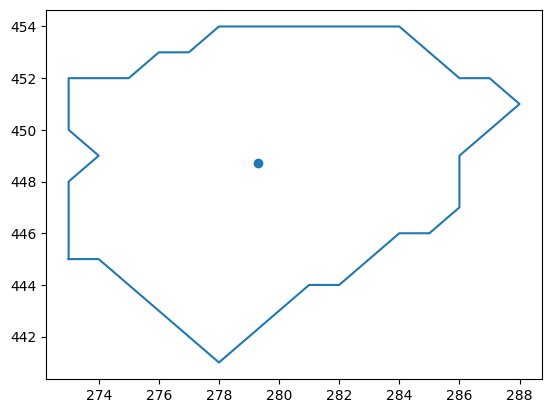

In [266]:
plt.plot(c[:, 0], c[:, 1])
plt.scatter(com[0], com[1])

In [148]:
dm.pmd_array.device

device(type='cuda', index=0)

In [134]:
def area_to_hull(a: np.ndarray) -> np.ndarray:
    """
    Get the vertices of a convex hull generated from an area represented by a binary mask
    :param a: binary mask
    :return: 2D array of x-y coordinates for the hull vertices
    """
    xs, ys = np.where(a)
    points = np.array((xs, ys)).T
    hull = ConvexHull(points, qhull_options='Qt')
    vs = points[hull.vertices[hull.vertices < points.shape[0]]]
    return vs

In [136]:
pts = area_to_hull(A)

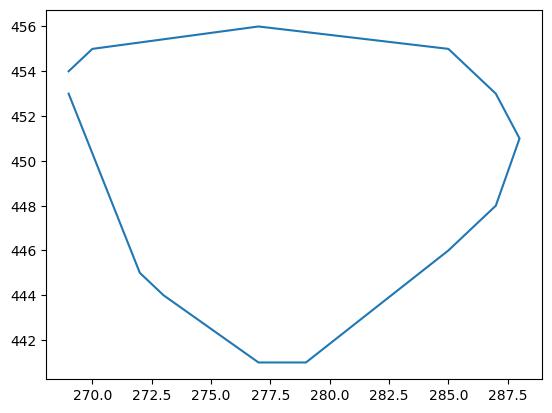

In [137]:
plt.plot(pts[:, 0], pts[:, 1])

RFBOutputContext()

/home/kushal/repos/fastplotlib/fastplotlib/graphics/features/_base.py:18: UserWarning: casting float64 array to float32
  warn(f"casting {array.dtype} array to float32")


JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
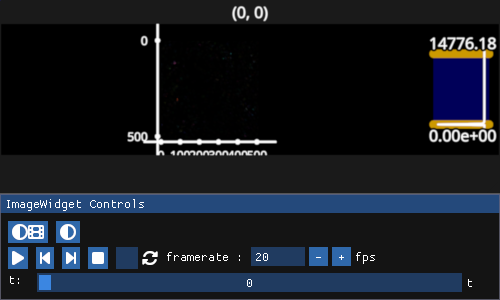

In [8]:
fpl.ImageWidget(dm.colorful_ac_array, rgb=True).show()

In [21]:
dm.residual_array

RFBOutputContext()

/home/kushal/repos/fastplotlib/fastplotlib/graphics/features/_base.py:18: UserWarning: casting float64 array to float32
  warn(f"casting {array.dtype} array to float32")


JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
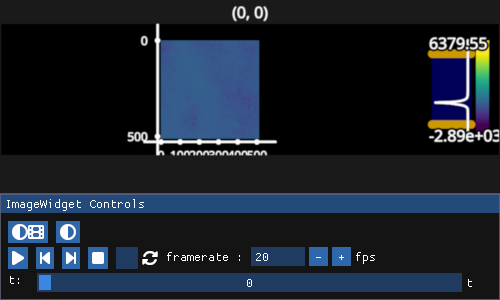

In [31]:
fpl.ImageWidget(dm.fluctuating_background_array, cmap="viridis").show()

RFBOutputContext()

/home/kushal/repos/fastplotlib/fastplotlib/graphics/features/_base.py:18: UserWarning: casting float64 array to float32
  warn(f"casting {array.dtype} array to float32")


JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
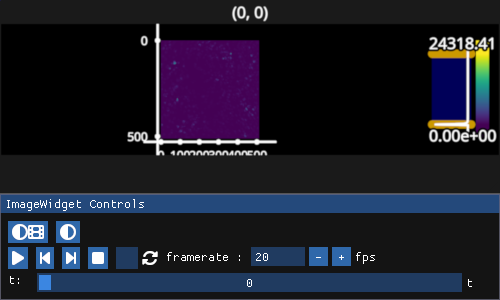

In [18]:
iw = fpl.ImageWidget(dm.ac_array, cmap="viridis")
iw.show()

RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
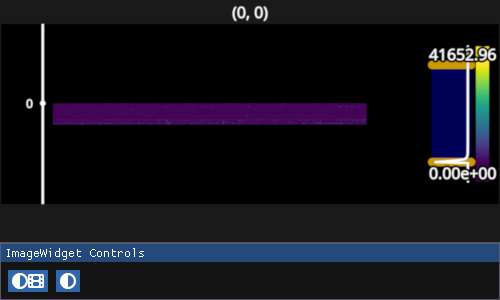

In [22]:
fpl.ImageWidget(dm.c.T.numpy(), cmap="viridis").show()

In [ ]:
iw = masknmf.visualization.make_demixing_video(demixing_results,
                                               device="cuda",
                                               v_range = [-100, 5000],
                                               show_histogram = True)
iw.show()